# <font color='orange'>**Introduction to Scikit-learn and K-Nearest Neighbors**</font>

KNN operates on the principle of similarity. It assumes that similar things exist in close proximity.

## Importing Libraries and Modules

In [ ]:
# import required packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
import seaborn as sns

from sklearn.datasets import make_regression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

from sklearn.datasets import fetch_openml
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

### Task 1: Load and Data Analysis
1. Load the Boston Housing dataset from OpenML (ID=531).
2. Data Profiling:
  - Correlation HeatMap
  - Pairplot of Selected Features
  - Feature vs. Target (Scatter Plots)
  - Distribution of Target (MEDV)

#### Load the Boston Housing dataset from OpenML (ID=531).

In [ ]:
# Load Boston housing dataset from OpenML
boston = fetch_openml(data_id=531, as_frame=True)
X = boston.data
y = boston.target


###Plots

In [ ]:
# Combine features and target into a single DataFrame
df = X.copy()
df['MEDV'] = y  # MEDV = Median value of owner-occupied homes

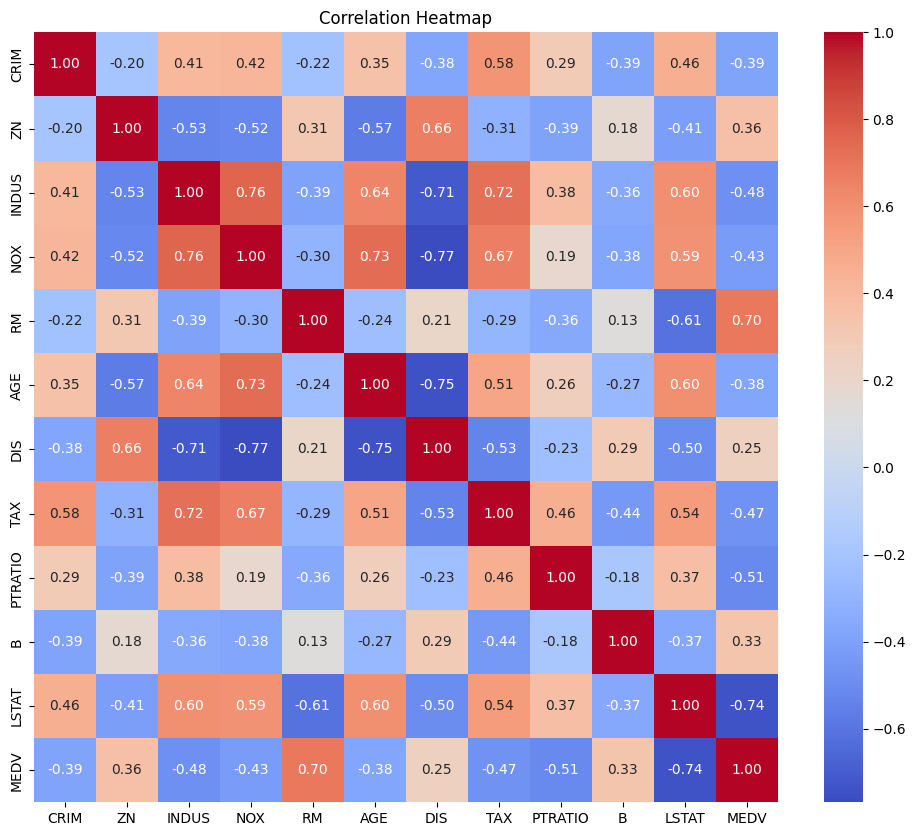

In [ ]:
# Correlation HeatMap
plt.figure(figsize=(12, 10))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


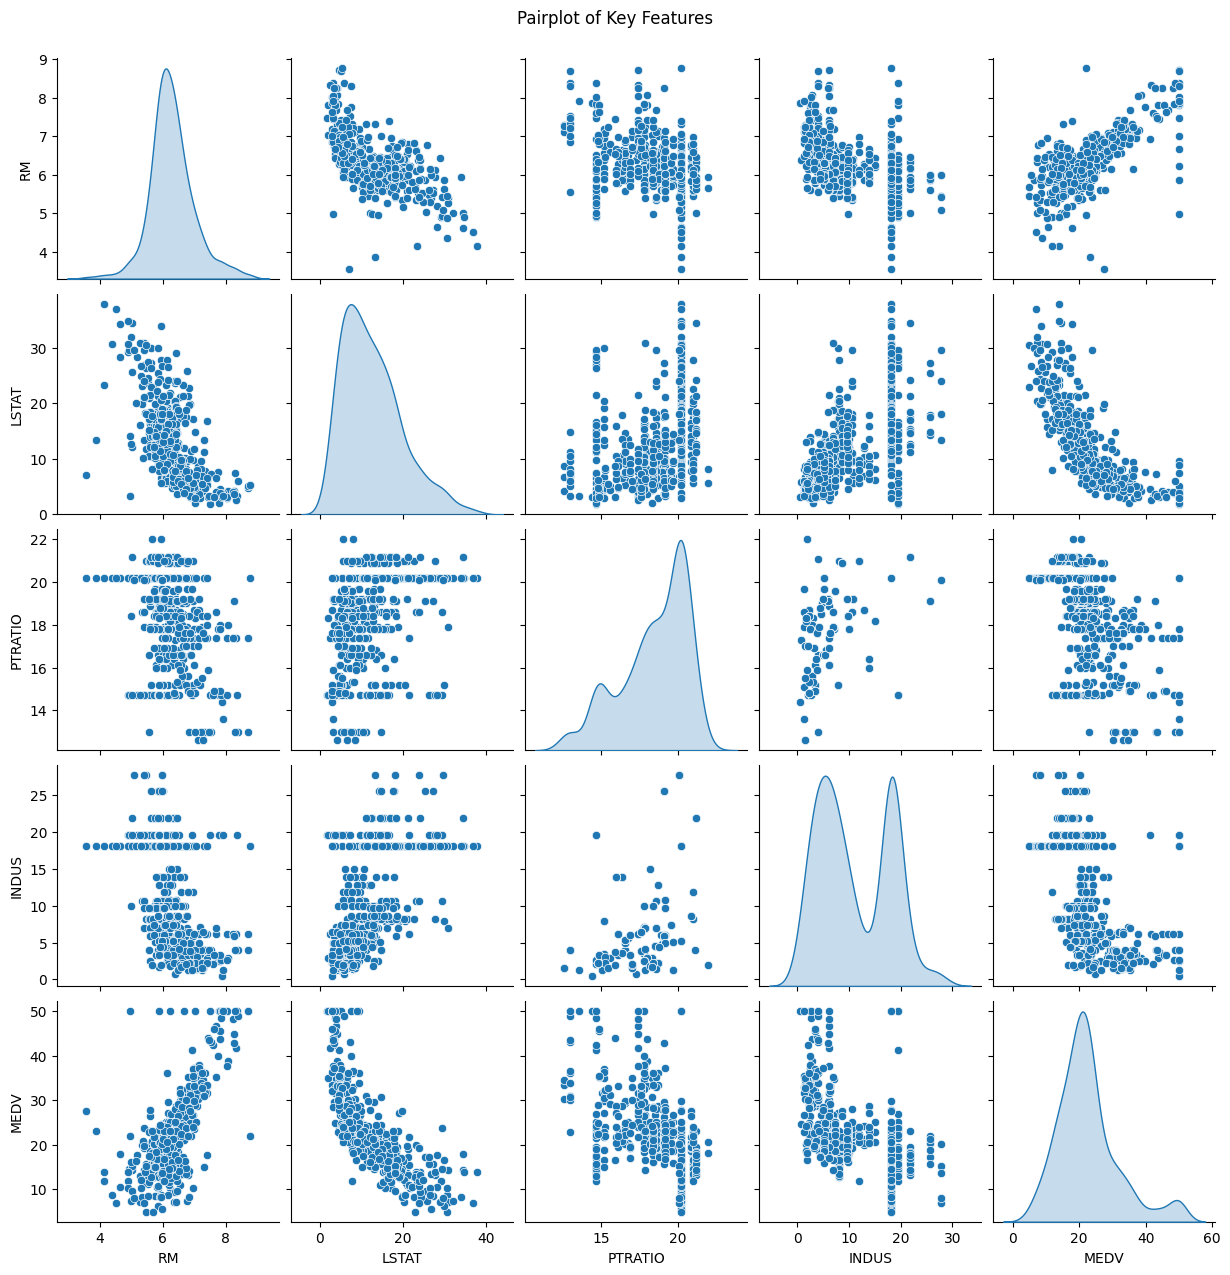

In [ ]:
# Pairplot of Selected Features
selected_features = ['RM', 'LSTAT', 'PTRATIO', 'INDUS', 'MEDV']
sns.pairplot(df[selected_features], diag_kind="kde")
plt.suptitle("Pairplot of Key Features", y=1.02)
plt.show()

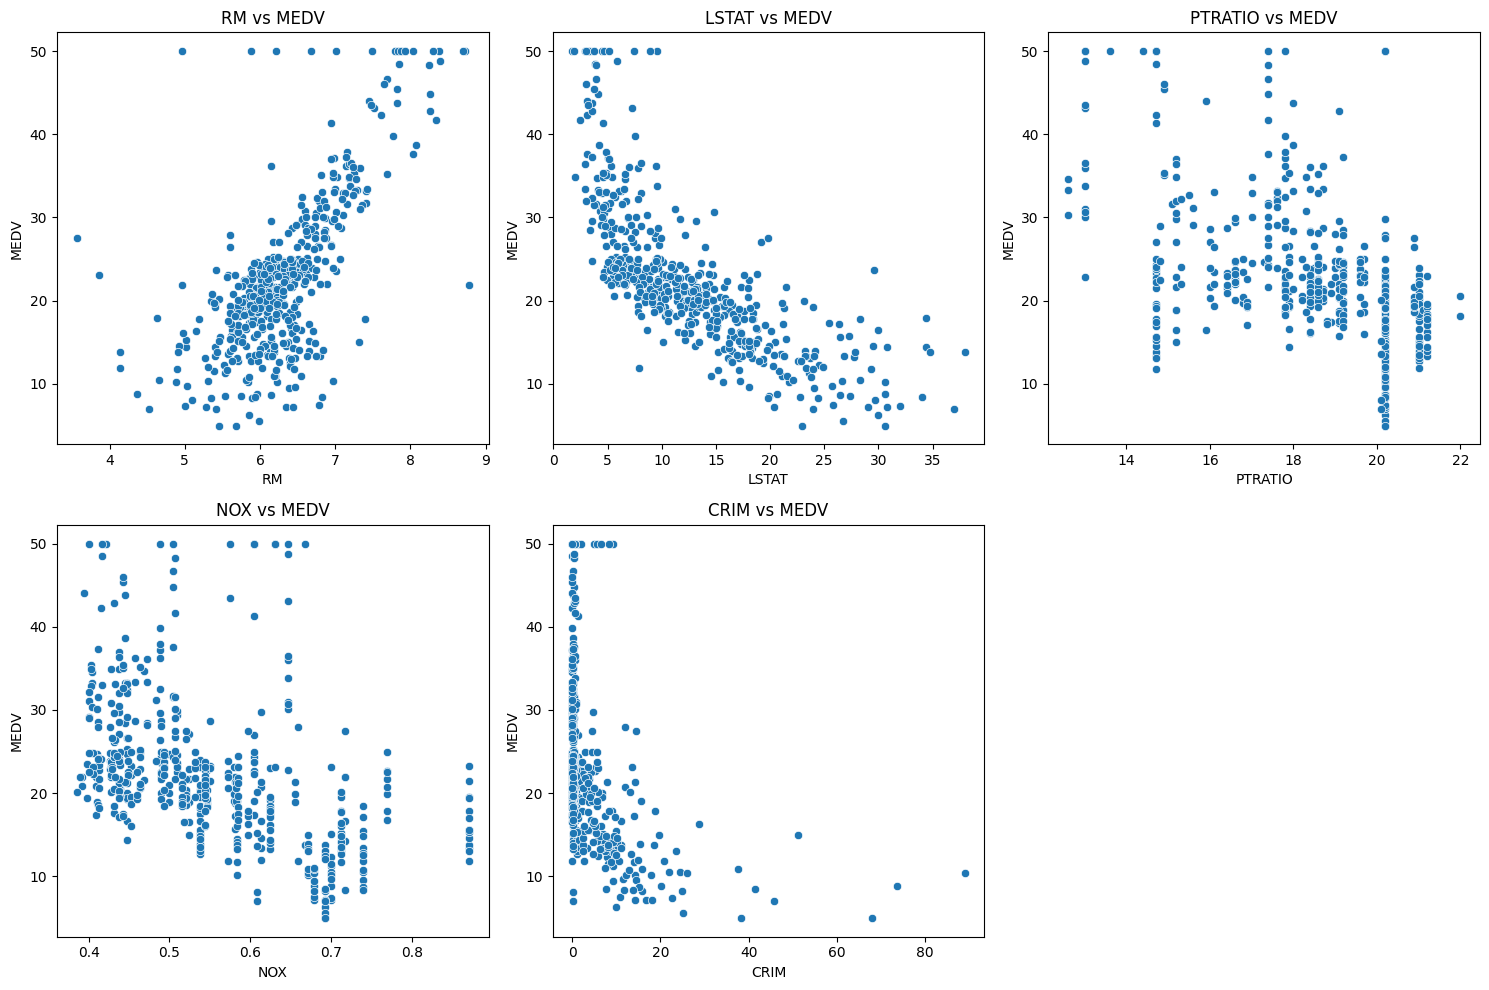

In [ ]:
# Feature vs. Target (Scatter Plots)
features = ['RM', 'LSTAT', 'PTRATIO', 'NOX', 'CRIM']
plt.figure(figsize=(15, 10))

for i, feature in enumerate(features, 1):
    plt.subplot(2, 3, i)
    sns.scatterplot(x=df[feature], y=df['MEDV'])
    plt.title(f"{feature} vs MEDV")
    plt.xlabel(feature)
    plt.ylabel("MEDV")

plt.tight_layout()
plt.show()


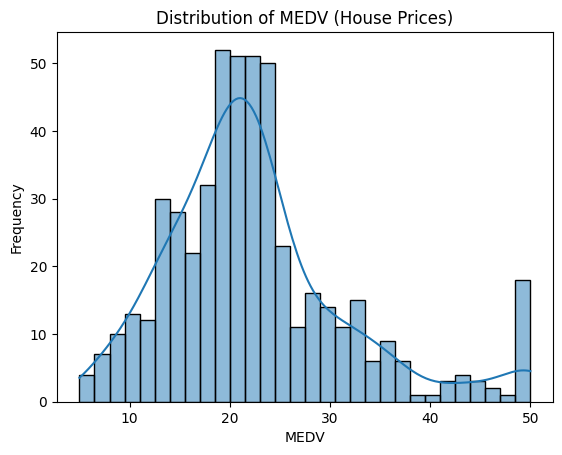

In [ ]:
# Distribution of Target (MEDV)
sns.histplot(df['MEDV'], kde=True, bins=30)
plt.title("Distribution of MEDV (House Prices)")
plt.xlabel("MEDV")
plt.ylabel("Frequency")
plt.show()


### Task 1.1: Scaling and Splitting the data
1. Scale the features so that all are in the same range (e.g., using Min-Max scaling).
2. Split the dataset into training and testing sets, with 80% training and 20% testing.

#### Scale the features so that all are in the same range (e.g., using Min-Max scaling).

In [ ]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)


#### Split the dataset into training and testing sets, with 80% training and 20% testing.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)


### Task 2: Implement KNN Regressor from Scratch
1. Implement a KNN regressor from scratch- Simple Average
  
2. Support the following distance metrics:

  2.1. Euclidean distance

  2.2. Manhattan distance

  2.3. Cosine distance

3. For different values of k (e.g., 3, 5, 7, 9, 11), predict test set targets and compute R² scores for each combination of k and distance metric.
4. Create a table summarizing the R² scores for each (k, distance metric) pair.

#### Handler Functions

In [ ]:
def compute_distance(x1, x2, metric='euclidean'):
    if metric == 'euclidean':
        return np.linalg.norm(x1 - x2)
    elif metric == 'manhattan':
        return np.sum(np.abs(x1 - x2))
    elif metric == 'cosine':
        # cosine distance = 1 - cosine similarity
        # cosine similarity = dot(a,b) / (||a|| * ||b||)
        dot = np.dot(x1, x2)
        norm_x1 = np.linalg.norm(x1)
        norm_x2 = np.linalg.norm(x2)
        if norm_x1 == 0 or norm_x2 == 0:
            # Handle zero vector case
            return 1.0
        cosine_sim = dot / (norm_x1 * norm_x2)
        return 1 - cosine_sim
    else:
        raise ValueError(f"Unsupported metric: {metric}")

# Hyperparameters
k_vals = [3, 5, 7, 9, 11]
metrics = ['euclidean', 'manhattan', 'cosine']

#### Simple Average KNN

In [ ]:
class KNNRegressorCustom:
    def __init__(self, k=5, metric='euclidean'):
        self.k = k
        self.metric = metric

    def fit(self, X, y):
        self.X_train = np.array(X)
        self.y_train = np.array(y)

    def predict(self, X):
        preds = []
        for x in X:
            distances = np.array([compute_distance(x, train_x, self.metric) for train_x in self.X_train])
            idx = np.argsort(distances)[:self.k]
            pred = np.mean(self.y_train[idx])
            preds.append(pred)
        return np.array(preds)


In [ ]:
results = []

for k in k_vals:
    for metric in metrics:
        model = KNNRegressorCustom(k=k, metric=metric)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        r2 = r2_score(y_test, y_pred)
        results.append((k, metric, r2))
        print(f"k={k}, metric={metric}, R²={r2:.4f}")

k=3, metric=euclidean, R²=0.7225
k=3, metric=manhattan, R²=0.7385
k=3, metric=cosine, R²=0.7282
k=5, metric=euclidean, R²=0.7048
k=5, metric=manhattan, R²=0.7562
k=5, metric=cosine, R²=0.7080
k=7, metric=euclidean, R²=0.6703
k=7, metric=manhattan, R²=0.7143
k=7, metric=cosine, R²=0.6801
k=9, metric=euclidean, R²=0.6423
k=9, metric=manhattan, R²=0.6888
k=9, metric=cosine, R²=0.6448
k=11, metric=euclidean, R²=0.6460
k=11, metric=manhattan, R²=0.6602
k=11, metric=cosine, R²=0.6185


In [ ]:
y_train = y_train.reset_index(drop=True)

### Task 3: Compare with scikit-learn Simple KNN
1. Identify the (k, distance metric) combination that gave the best R² score from your custom implementation.
2. Use scikit-learn’s KNeighborsRegressor with algorithm='brute', weights='uniform', and the same (k, distance metric) to train and test on the dataset.
3. Compare the R² score of the scikit-learn model with your custom implementation for that best configuration.

In [ ]:
#Special Setup for SK Learn
best_k, best_metric, _ = max(results, key=lambda x: x[2])  # max R²
metric_map = {'euclidean': 2, 'manhattan': 1}  # cosine not supported by sklearn KNeighborsRegressor

if best_metric != 'cosine':
  print(best_metric)
else:
    print("Scikit-learn KNeighborsRegressor does not support cosine distance.")
    best_metric = 'euclidean'

manhattan


#### SK Learn KNN (Uniform)

In [ ]:
# Uniform weights (simple average)
model_uniform = KNeighborsRegressor(
    n_neighbors=best_k,
    p=metric_map[best_metric],
    algorithm='brute',
    weights='uniform'
)
model_uniform.fit(X_train, y_train)
y_pred_uniform = model_uniform.predict(X_test)
r2_uniform = r2_score(y_test, y_pred_uniform)
print(f"Scikit-learn Uniform weights: k={best_k}, metric={best_metric} → R²={r2_uniform:.4f}")

Scikit-learn Uniform weights: k=5, metric=manhattan → R²=0.7562


In [ ]:
# To store results
sklearn_results = []
metrics = ['euclidean', 'manhattan']

# Loop through each (k, metric) combination
for k in k_vals:
    for metric in metrics:
        p = metric_map[metric]

        model = KNeighborsRegressor(
            n_neighbors=k,
            p=p,
            algorithm='brute',
            weights='uniform'  # optional, since 'uniform' is default
        )
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        r2 = r2_score(y_test, y_pred)

        sklearn_results.append({
            'k': k,
            'metric': metric,
            'p': p,
            'r2_score': r2
        })
        print(f"k={k}, metric={metric}, p={p} → R²={r2:.4f}")

k=3, metric=euclidean, p=2 → R²=0.7225
k=3, metric=manhattan, p=1 → R²=0.7385
k=5, metric=euclidean, p=2 → R²=0.7048
k=5, metric=manhattan, p=1 → R²=0.7562
k=7, metric=euclidean, p=2 → R²=0.6703
k=7, metric=manhattan, p=1 → R²=0.7143
k=9, metric=euclidean, p=2 → R²=0.6423
k=9, metric=manhattan, p=1 → R²=0.6888
k=11, metric=euclidean, p=2 → R²=0.6460
k=11, metric=manhattan, p=1 → R²=0.6602


### Task 4: Implement Weighted KNN Regressor from Scratch
1. Implement a weighted average KNN regressor from scratch, where weights are the inverse of the distance to neighbors.
  
2. Support the following distance metrics:

  2.1. Euclidean distance

  2.2. Manhattan distance

  2.3. Cosine distance

3. For different values of k (e.g., 3, 5, 7, 9, 11), predict test set targets and compute R² scores for each combination of k and distance metric.
4. Create a table summarizing the R² scores for each (k, distance metric) pair.

#### Average Weighted KNN

In [ ]:
class WeightedKNNRegressor(KNNRegressorCustom):
    def predict(self, X):
        preds = []
        for x in X:
            distances = np.array([compute_distance(x, train_x, self.metric) for train_x in self.X_train])
            idx = np.argsort(distances)[:self.k]
            nearest_distances = distances[idx]
            nearest_targets = self.y_train[idx]

            # To avoid division by zero
            nearest_distances = np.where(nearest_distances == 0, 1e-10, nearest_distances)

            # Calculate weights as inverse of distance
            weights = 1 / nearest_distances

            # Weighted average prediction
            pred = np.sum(weights * nearest_targets) / np.sum(weights)
            preds.append(pred)
        return np.array(preds)

In [ ]:
results_wt = []
for k in k_vals:
    for metric in metrics:
        model = WeightedKNNRegressor(k=k, metric=metric)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        r2 = r2_score(y_test, y_pred)
        results_wt.append((k, metric, r2))
        print(f"k={k}, metric={metric}, R²={r2:.4f}")


k=3, metric=euclidean, R²=0.7422
k=3, metric=manhattan, R²=0.7465
k=5, metric=euclidean, R²=0.7291
k=5, metric=manhattan, R²=0.7711
k=7, metric=euclidean, R²=0.7016
k=7, metric=manhattan, R²=0.7367
k=9, metric=euclidean, R²=0.6792
k=9, metric=manhattan, R²=0.7183
k=11, metric=euclidean, R²=0.6811
k=11, metric=manhattan, R²=0.6925


### Task 5: Compare with scikit-learn Weighted KNN
1. Identify the best (k, distance metric) combination from your weighted KNN results.

2. Use scikit-learn’s KNeighborsRegressor with algorithm='brute' and weights='distance' for the same (k, distance metric).



#### SK Learn Weighted.

In [ ]:
# Distance weights (weighted average)
model_distance = KNeighborsRegressor(
    n_neighbors=best_k,
    p=metric_map[best_metric],
    algorithm='brute',
    weights='distance'
)
model_distance.fit(X_train, y_train)
y_pred_distance = model_distance.predict(X_test)
r2_distance = r2_score(y_test, y_pred_distance)
print(f"Scikit-learn Distance weights: k={best_k}, metric={best_metric} → R²={r2_distance:.4f}")

Scikit-learn Distance weights: k=5, metric=manhattan → R²=0.7711


In [ ]:
# To store results
sklearn_results_weighted = []
# metrics = ['euclidean', 'manhattan']

# Loop through each (k, metric) combination
for k in k_vals:
    for metric in metrics:
        p = metric_map[metric]

        model = KNeighborsRegressor(
            n_neighbors=k,
            p=p,
            algorithm='brute',
            weights='uniform'  # optional, since 'uniform' is default
        )
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        r2 = r2_score(y_test, y_pred)

        sklearn_results_weighted.append({
            'k': k,
            'metric': metric,
            'p': p,
            'r2_score': r2
        })
        print(f"k={k}, metric={metric}, p={p} → R²={r2:.4f}")

k=3, metric=euclidean, p=2 → R²=0.7225
k=3, metric=manhattan, p=1 → R²=0.7385
k=5, metric=euclidean, p=2 → R²=0.7048
k=5, metric=manhattan, p=1 → R²=0.7562
k=7, metric=euclidean, p=2 → R²=0.6703
k=7, metric=manhattan, p=1 → R²=0.7143
k=9, metric=euclidean, p=2 → R²=0.6423
k=9, metric=manhattan, p=1 → R²=0.6888
k=11, metric=euclidean, p=2 → R²=0.6460
k=11, metric=manhattan, p=1 → R²=0.6602


### Task 6: Reporting and Visualization
1. Plot the R² scores for both simple and weighted KNN from your implementation across different k and distance metrics (heatmap or line plots).

2. Plot corresponding R² scores from scikit-learn for the same parameters.

3. Compare the R² scores of scikit-learn weighted KNN with your custom weighted KNN for the best combination.

4. Plotting the Scatter Plots of the actual and predicted datapoints

#### Plot the R² scores for both simple and weighted KNN from your implementation across different k and distance metrics (heatmap or line plots).

/tmp/ipython-input-65-1139401241.py:11: UserWarning: Glyph 128295 (\N{WRENCH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128295 (\N{WRENCH}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


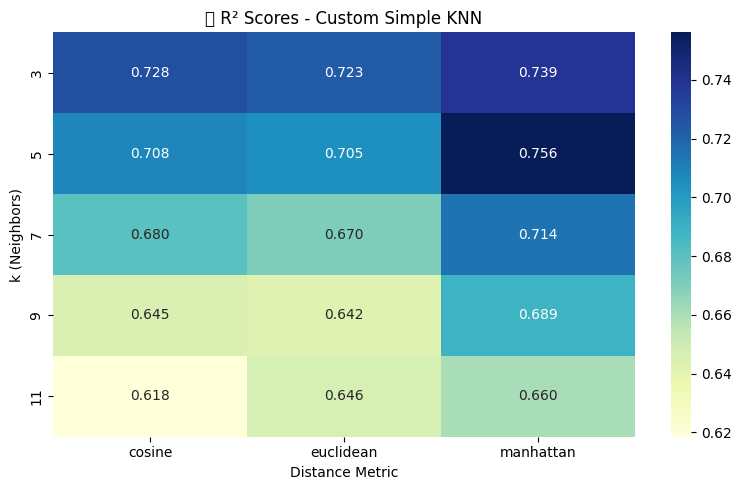

In [ ]:
# Convert your results to DataFrames
df_simple = pd.DataFrame(results, columns=['k', 'metric', 'r2'])

pivot_simple = df_simple.pivot_table(index='k', columns='metric', values='r2', aggfunc='mean')

plt.figure(figsize=(8, 5))
sns.heatmap(pivot_simple, annot=True, cmap='YlGnBu', fmt=".3f")
plt.title("🔧 R² Scores - Custom Simple KNN")
plt.xlabel("Distance Metric")
plt.ylabel("k (Neighbors)")
plt.tight_layout()
plt.show()


In [ ]:
print(results_wt)

[(3, 'euclidean', 0.7422109620652408), (3, 'manhattan', 0.7464917953182264), (5, 'euclidean', 0.7290755509754219), (5, 'manhattan', 0.7710963242080996), (7, 'euclidean', 0.7015667380070771), (7, 'manhattan', 0.7366556251169165), (9, 'euclidean', 0.6791561130423782), (9, 'manhattan', 0.7182738626267138), (11, 'euclidean', 0.6810762206508555), (11, 'manhattan', 0.6925457502508152)]


/tmp/ipython-input-67-3812832604.py:9: UserWarning: Glyph 128295 (\N{WRENCH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128295 (\N{WRENCH}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


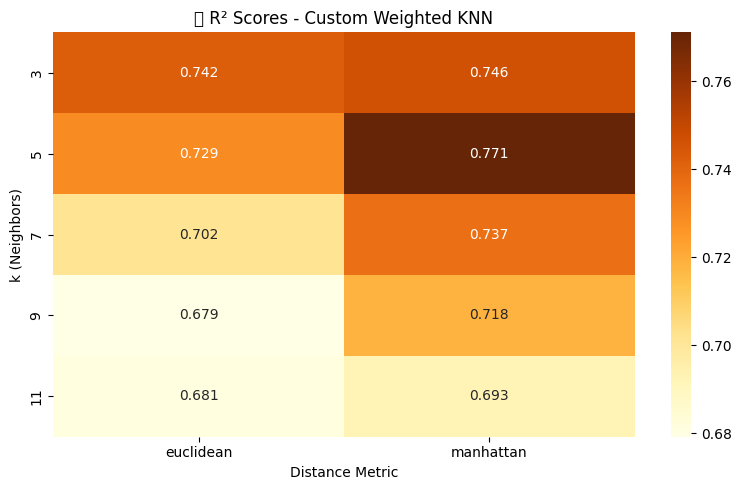

In [ ]:
df_weighted = pd.DataFrame(results_wt, columns=['k', 'metric', 'r2'])
pivot_weighted = df_weighted.pivot_table(index='k', columns='metric', values='r2', aggfunc='mean')

plt.figure(figsize=(8, 5))
sns.heatmap(pivot_weighted, annot=True, cmap='YlOrBr', fmt=".3f")
plt.title("🔧 R² Scores - Custom Weighted KNN")
plt.xlabel("Distance Metric")
plt.ylabel("k (Neighbors)")
plt.tight_layout()
plt.show()


#### Plot corresponding R² scores from scikit-learn for the same parameters.

/tmp/ipython-input-68-312307183.py:12: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


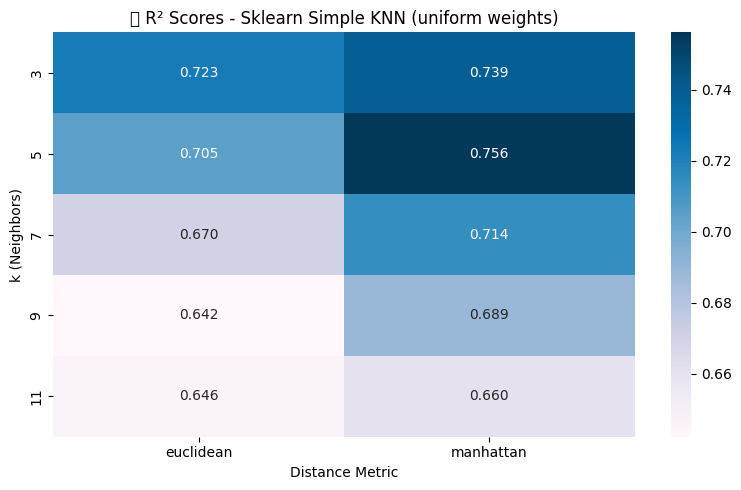

In [ ]:
df_sklearn_simple = pd.DataFrame(sklearn_results)
pivot_sklearn_simple = df_sklearn_simple.pivot_table(index='k', columns='metric', values='r2_score', aggfunc='mean')

# Drop all-NaN rows/columns if any
pivot_sklearn_simple = pivot_sklearn_simple.dropna(how='all').dropna(axis=1, how='all')

plt.figure(figsize=(8, 5))
sns.heatmap(pivot_sklearn_simple, annot=True, cmap='PuBu', fmt=".3f")
plt.title("🤖 R² Scores - Sklearn Simple KNN (uniform weights)")
plt.xlabel("Distance Metric")
plt.ylabel("k (Neighbors)")
plt.tight_layout()
plt.show()

/tmp/ipython-input-69-3992210745.py:12: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


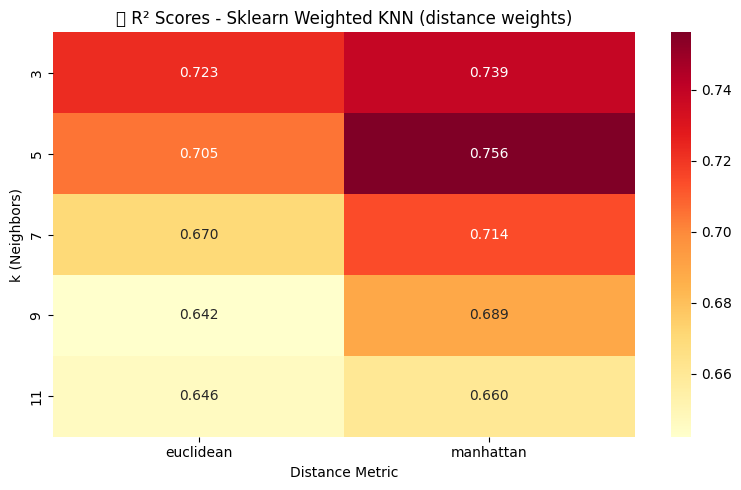

In [ ]:
df_sklearn_weighted = pd.DataFrame(sklearn_results_weighted)
pivot_sklearn_weighted = df_sklearn_weighted.pivot_table(index='k', columns='metric', values='r2_score', aggfunc='mean')

# Drop all-NaN rows/columns if any
pivot_sklearn_weighted = pivot_sklearn_weighted.dropna(how='all').dropna(axis=1, how='all')

plt.figure(figsize=(8, 5))
sns.heatmap(pivot_sklearn_weighted, annot=True, cmap='YlOrRd', fmt=".3f")
plt.title("🤖 R² Scores - Sklearn Weighted KNN (distance weights)")
plt.xlabel("Distance Metric")
plt.ylabel("k (Neighbors)")
plt.tight_layout()
plt.show()

#### Compare the R² scores of scikit-learn weighted KNN with your custom weighted KNN for the best combination.

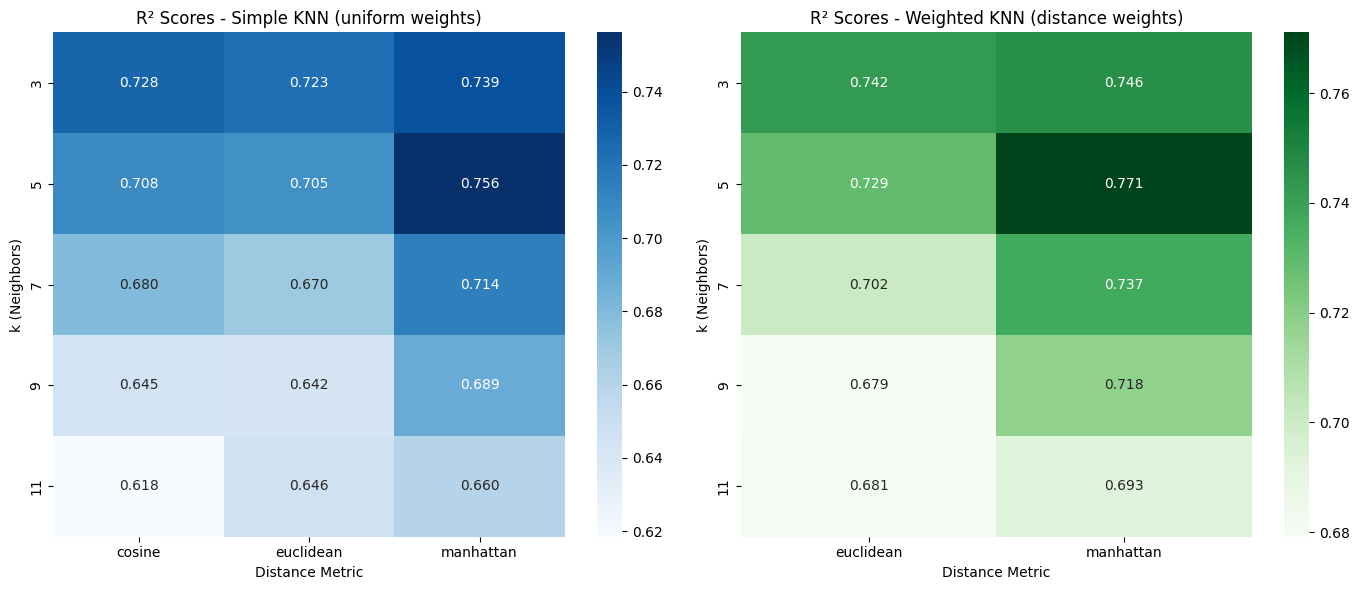

In [ ]:
# Plot side by side heatmaps
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.heatmap(pivot_simple, annot=True, cmap='Blues', fmt=".3f")
plt.title("R² Scores - Simple KNN (uniform weights)")
plt.xlabel("Distance Metric")
plt.ylabel("k (Neighbors)")

plt.subplot(1, 2, 2)
sns.heatmap(pivot_weighted, annot=True, cmap='Greens', fmt=".3f")
plt.title("R² Scores - Weighted KNN (distance weights)")
plt.xlabel("Distance Metric")
plt.ylabel("k (Neighbors)")

plt.tight_layout()
plt.show()

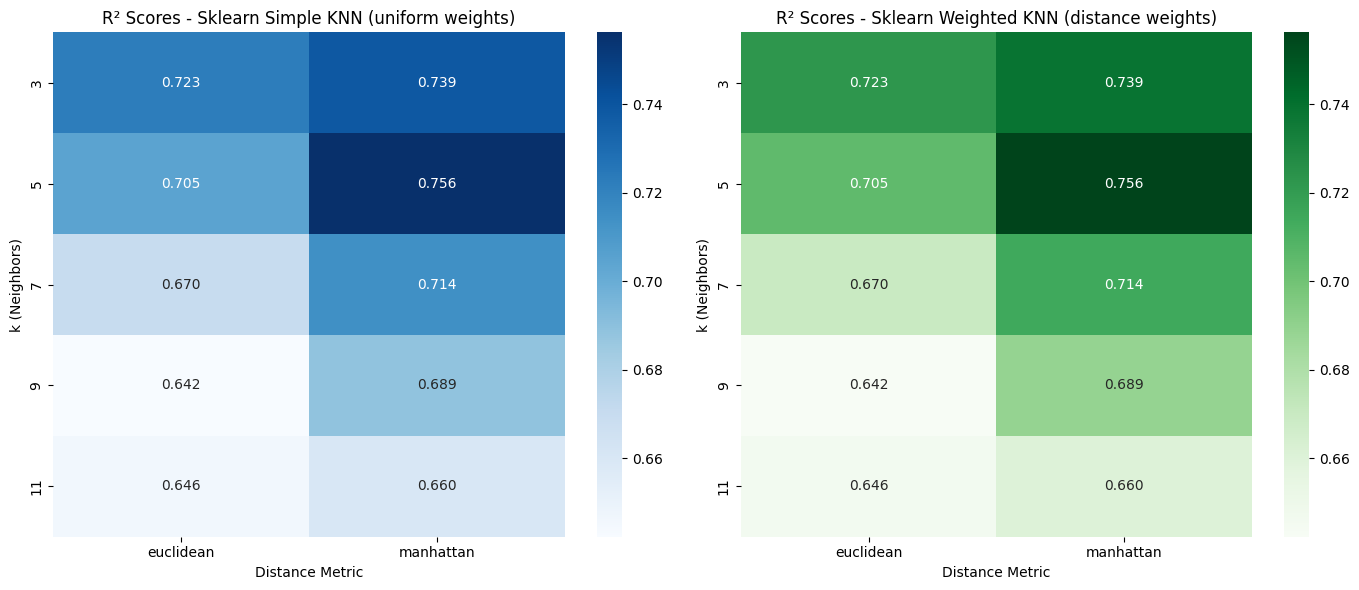

In [ ]:
# Plot side by side heatmaps
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.heatmap(pivot_sklearn_simple, annot=True, cmap='Blues', fmt=".3f")
plt.title("R² Scores - Sklearn Simple KNN (uniform weights)")
plt.xlabel("Distance Metric")
plt.ylabel("k (Neighbors)")

plt.subplot(1, 2, 2)
sns.heatmap(pivot_sklearn_weighted, annot=True, cmap='Greens', fmt=".3f")
plt.title("R² Scores - Sklearn Weighted KNN (distance weights)")
plt.xlabel("Distance Metric")
plt.ylabel("k (Neighbors)")

plt.tight_layout()
plt.show()

#### Plotting the Scatter Plots of the actual and predicted datapoints

In [ ]:
# Get best sklearn model based on highest R²
best_sk = df_sklearn_simple.loc[df_sklearn_simple['r2_score'].idxmax()]
best_k_sk = best_sk['k']
best_metric_sk = best_sk['metric']
best_p_sk = metric_map[best_metric_sk]

# Retrain and predict
model_sk = KNeighborsRegressor(n_neighbors=best_k_sk, p=best_p_sk, algorithm='brute', weights='uniform')
model_sk.fit(X_train, y_train)
y_pred_sk = model_sk.predict(X_test)


In [ ]:
# Find best custom weighted model
best_wt = max(results_wt, key=lambda x: x[2])
best_k_wt, best_metric_wt, _ = best_wt

# Predict using custom WeightedKNNRegressor
model_wt = WeightedKNNRegressor(k=best_k_wt, metric=best_metric_wt)
model_wt.fit(X_train, y_train)
y_pred_wt = model_wt.predict(X_test)


In [ ]:
def scatter_plot_actual_vs_pred(y_test, y_pred, model_name, k, metric, r2):
    plt.figure(figsize=(6.5, 6.5))
    sns.scatterplot(x=y_test, y=y_pred, color='steelblue', edgecolor='k', alpha=0.7)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')

    plt.xlabel("Actual House Prices")
    plt.ylabel("Predicted House Prices")
    plt.title(f"{model_name} (k={k}, metric={metric})\nR² Score = {r2:.4f}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


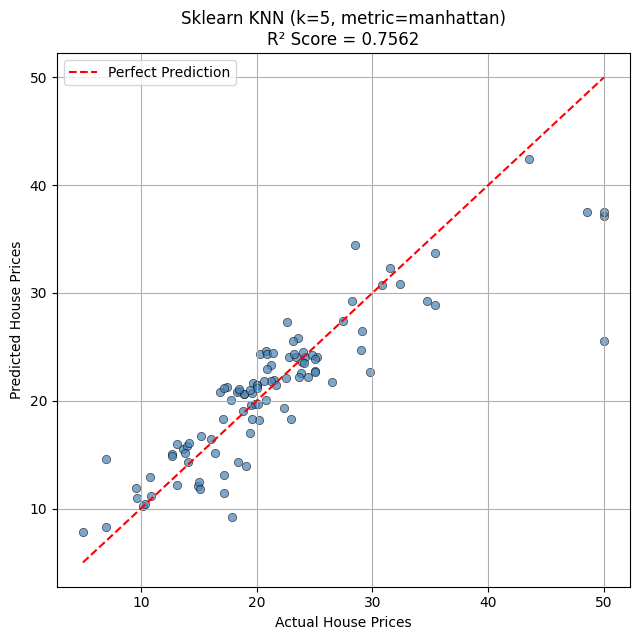

In [ ]:
r2_sk = r2_score(y_test, y_pred_sk)
scatter_plot_actual_vs_pred(y_test, y_pred_sk, "Sklearn KNN", best_k_sk, best_metric_sk, r2_sk)



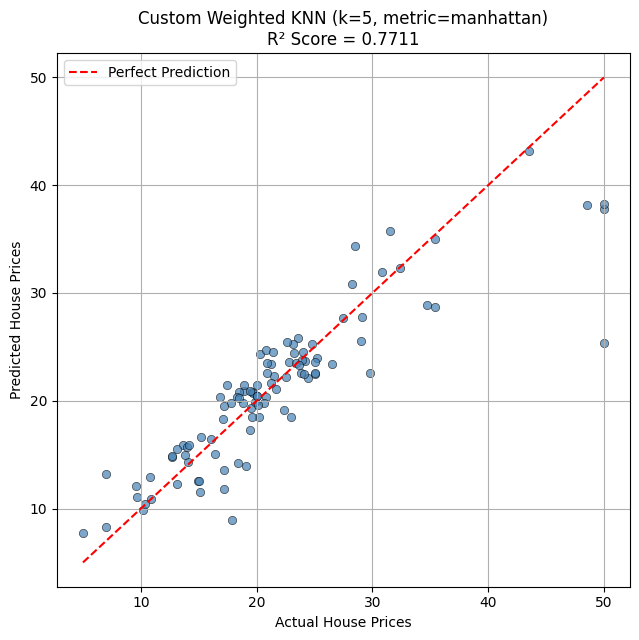

In [ ]:

r2_wt = r2_score(y_test, y_pred_wt)
scatter_plot_actual_vs_pred(y_test, y_pred_wt, "Custom Weighted KNN", best_k_wt, best_metric_wt, r2_wt)

### Task 7: Summarize your findings:

- Which (k, distance metric) performed best?

- How does your implementation compare with scikit-learn?

- Discuss any observations regarding distance metrics or weighting.